<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter04/07-Data_augmentation_with_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torchvision import datasets

import torchvision.transforms as transforms 

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
import imgaug.augmenters as iaa

# 定义 imgaug 增强
augmenter = iaa.Sequential([
    iaa.Affine(translate_px={'x':(-10,10)},
        mode='constant'),

    # iaa.Affine(rotate=(-30, 30)),  # 随机旋转 -30 到 30 度
    # iaa.Fliplr(0.5),              # 50% 概率水平翻转
    # iaa.Crop(percent=(0, 0.2)),   # 随机裁剪 0% 到 20% 边缘
    # iaa.Multiply((0.8, 1.2))      # 随机调整亮度
])

# 定义 imgaug 转换函数
def imgaug_transform(image):
    image = np.array(image)  # 将 PIL 图像转换为 numpy 数组
    image = augmenter(image=image)  # 应用 imgaug 增强
    return torch.tensor(image).float().div(255).unsqueeze(0)  # 转为张量并归一化

# 数据增强管道
train_transform = transforms.Compose([
    transforms.Lambda(imgaug_transform)  # 使用 Lambda 包装 imgaug
])
test_transform = transforms.Compose([
    transforms.ToTensor(),  # 测试集仅归一化
])

data_folder = '../data/FMNIST' # This can be any directory you want to download FMNIST to


def get_data(): 
    train_dataset = datasets.FashionMNIST(root=data_folder, train=True, transform=train_transform, download=True)
    test_dataset = datasets.FashionMNIST(root=data_folder, train=False, transform=test_transform, download=True)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
    return train_loader,test_loader

In [3]:
from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(3200, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

In [4]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

In [5]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()
for epoch in range(5):
    print(epoch)
    for x,y in trn_dl:
        x=x.to(device)
        y=y.to(device)
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

0
1
2
3
4


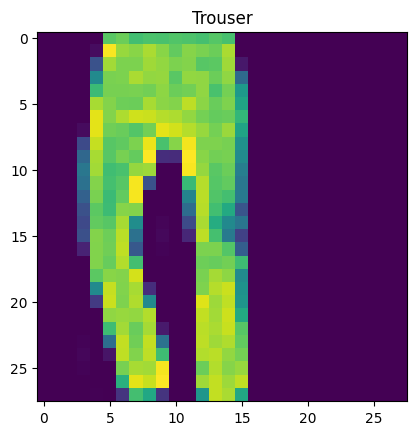

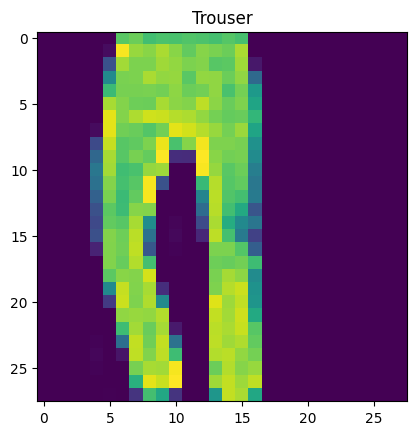

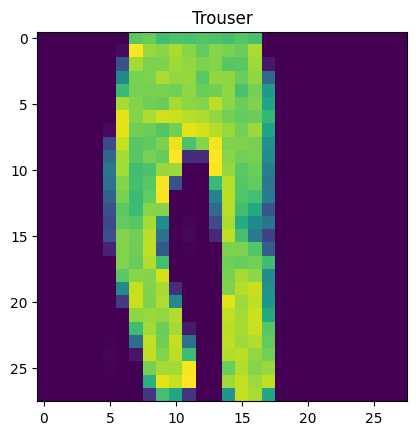

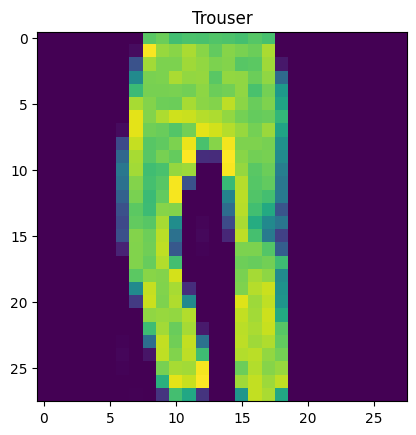

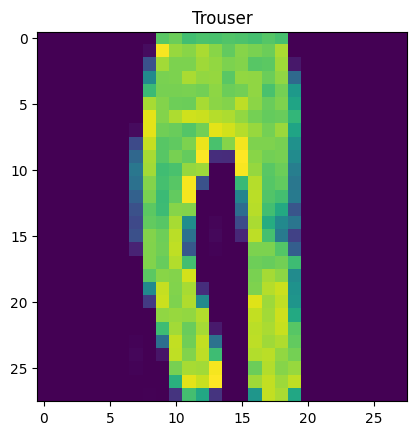

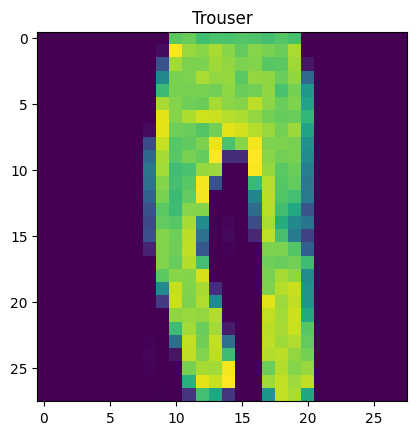

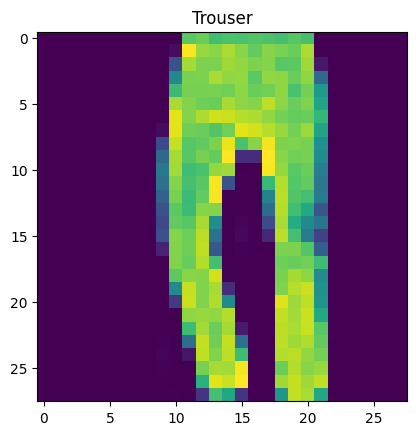

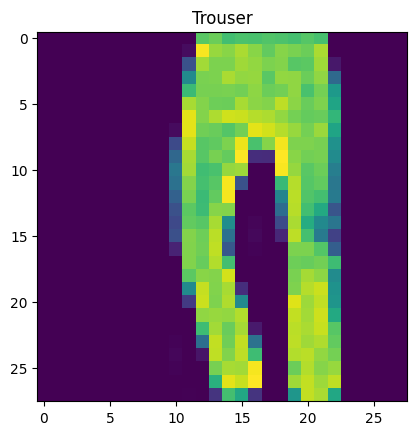

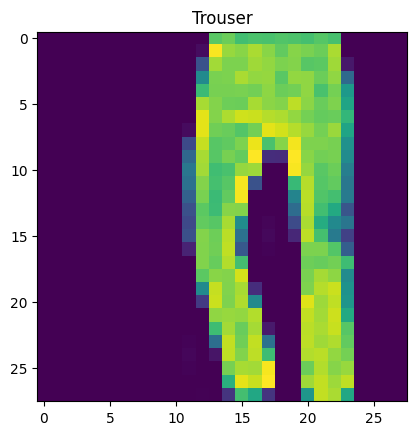

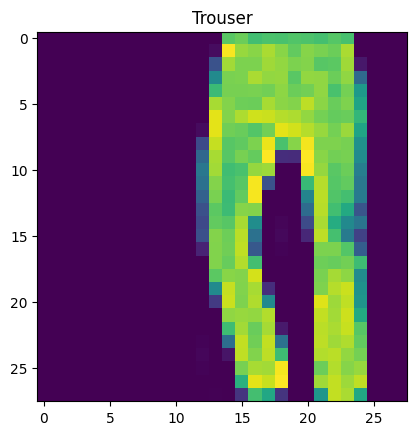

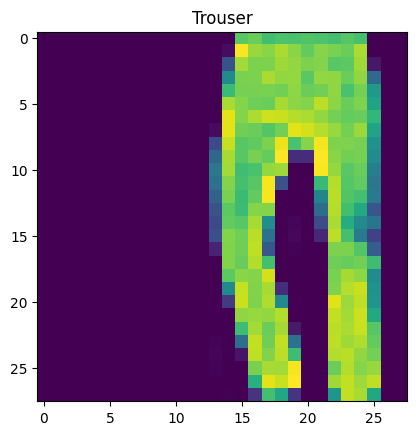

In [7]:
train_dataset = datasets.FashionMNIST(root=data_folder, train=True, transform=test_transform, download=True)
tr_images = train_dataset.data
tr_targets = train_dataset.targets

preds = []
ix = 24300
for px in range(-5,6):
    img = tr_images[ix]/255.
    img = img.view(28, 28)
    img2 = np.roll(img, px, axis=1)
    img3 = torch.Tensor(img2).view(-1,1,28,28).to(device)
    np_output = model(img3).cpu().detach().numpy()
    pred = np.exp(np_output)/np.sum(np.exp(np_output))
    preds.append(pred)
    plt.imshow(img2)
    plt.title(train_dataset.classes[pred[0].argmax()])
    plt.show()

<Axes: title={'center': 'Probability of each class for various translations'}>

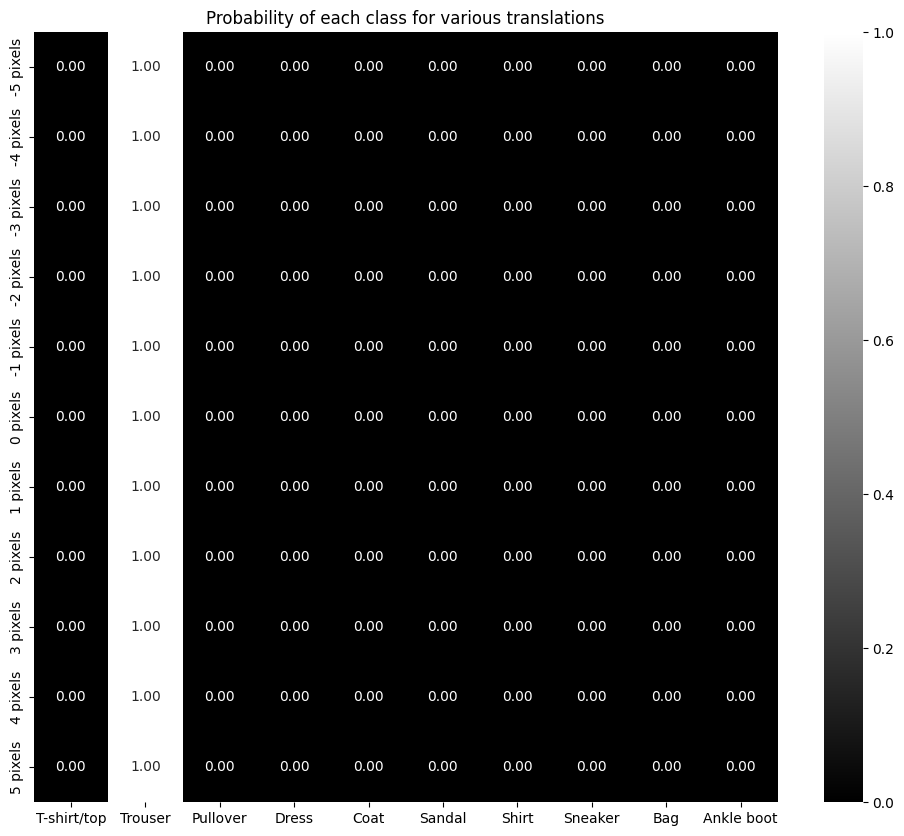

In [9]:
import seaborn as sns
fig, ax = plt.subplots(1,1, figsize=(12,10))
plt.title('Probability of each class for various translations')
sns.heatmap(np.array(preds).reshape(11,10), annot=True, ax=ax, fmt='.2f', xticklabels=train_dataset.classes, yticklabels=[str(i)+str(' pixels') for i in range(-5,6)], cmap='gray')